<a href="https://colab.research.google.com/github/MoeinRajabiGhaemiyeh/Regularization-and-Stability/blob/main/Regularization_and_Stability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [1]:
import random
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# Functions

In [2]:
# Defining subsample function which takes in the full dataset and returns a random subsample of size n
def subsample(X, Y, n, seed = 123):
  # Set a fixed random seed for reproducibility
  random.seed(seed)
  indices = random.sample(range(len(X)), n)
  return X.iloc[indices], Y.iloc[indices]

# Defining data split function which takes in the full dataset and splits it into training and testing sets based on the specified test size
def data_split(X, Y, test_size = 0.2, seed = 123):
  # Set a fixed random seed for reproducibility
  random.seed(seed)
  test_index = random.sample(X.index.tolist(), int(len(X.index) * test_size))
  X_train = X.drop(test_index)
  Y_train = Y.drop(test_index)
  X_test = X.loc[test_index]
  Y_test = Y.loc[test_index]
  return X_train, Y_train, X_test, Y_test

# Defining standardization function which takes in the training and testing sets and standardizes the features based on the training set statistics
def standardize(X_train, X_test = None):
  # Compute mean and std from training data
  Xmeans = X_train.mean()
  Xstds = X_train.std()
  # Standardize both training and testing data using training statistics
  X_train_scaled = (X_train - Xmeans) / Xstds
  if X_test is None:
      return X_train_scaled
  X_test_scaled = (X_test - Xmeans) / Xstds
  # Add Bias
  X_train_scaled.insert(0, 'bias', 1)
  X_test_scaled.insert(0, 'bias', 1)
  return X_train_scaled, X_test_scaled

def corr(X):
  # Compute correlation matrix for features
  n = X.shape[0]
  corr_matrix = np.matmul(X.T, X) / (n - 1)
  return corr_matrix

def dgp(n, features, weights = None, dist = 'normal', mu = 0, sigma = 0.5, weight_sigma = 1, intercept = 2, sparsity = 0.1, target_snr = 2, seed = 123):
  # Data Generating Process function
  # Set a fixed random seed for reproducibility
  np.random.seed(seed)
  # Check the input distribution for features
  if dist == 'normal':
    x = np.random.normal(mu, sigma, (n, features))
  elif dist == 'uniform':
    x = np.random.uniform(mu, sigma, (n, features))
  else:
    raise Exception('Invalid distribution')
  # Produce random weights if not pass to the function
  if weights is None:
    weights = np.random.normal(mu, weight_sigma, (features, 1))
  # Randomly make some features ineffective
  zero_indices = np.random.choice(features, int(sparsity * features), replace=False)
  weights[zero_indices] = 0
  # Calculate the required standard deviation for noise
  y_deterministic = np.matmul(x, weights) + intercept
  signal_variance = np.var(y_deterministic)
  noise_variance = signal_variance / target_snr
  noise_sigma = np.sqrt(noise_variance)
  noise = np.random.normal(0, noise_sigma, (n, 1))
  y = y_deterministic + noise
  return x, y, weights, noise


# Classes

In [3]:
# Defining RegressionModel class which implements ridge regression and supports leave-one-out cross-validation
class RegressionModel:
  # Initialize the model with training data, regularization parameter, and precompute necessary matrices for efficient fitting
  def __init__(self, X, Y, lambda_val = 0, index = None):
    self.X = X
    self.Y = Y
    self.lambda_val = lambda_val
    self.XTX = np.matmul(X.T, X)
    self.XTY = np.matmul(X.T, Y)
    self.I = np.eye(self.XTX.shape[0])
    self.I[0, 0] = 0
    self.w = None
    self.i = index

  # Fit the model to the training data, with an option for leave-one-out cross-validation
  def fit(self, loo = False, index = None):
      # If leave-one-out cross-validation is enabled, compute the model parameters by excluding the specified training example
    if loo:
      # Leave-one-out cross-validation
      self.i = index
      XTX_loo = self.XTX - np.matmul(self.X[self.i:self.i+1, :].T, self.X[self.i:self.i+1, :])
      XTY_loo = self.XTY - np.matmul(self.X[self.i:self.i+1, :].T, self.Y[self.i:self.i+1])
      self.w = np.linalg.solve(XTX_loo + self.lambda_val * self.I, XTY_loo)

    # Otherwise, compute the model parameters using the entire training dataset
    else:
      if self.lambda_val == 0:
        self.w = np.linalg.lstsq(self.XTX, self.XTY, rcond = None)[0]
      else:
        self.w = np.linalg.solve(self.XTX + self.lambda_val * self.I, self.XTY)

  # Predict the target values for the given input features using the learned model parameters
  def predict(self, X):
    return np.matmul(X, self.w)

# Defining Data class which handles data preprocessing steps including subsampling, splitting, and standardization
class Data:
    # Initialize the Data object with the full dataset and optional subsample size for preprocessing
  def __init__(self, X, Y, subsample_size = None):
    self.X = X
    self.Y = Y
    self.subsample_size = subsample_size

  # Split the dataset into training and testing sets, with an option for subsampling the training data if a subsample size is specified
  def split(self, test_size = 0.2):
    # Split before sampling results in having a universal test set for every model with every training set size
    self.X_train, self.Y_train, self.X_test, self.Y_test = data_split(self.X, self.Y, test_size)
    if self.subsample_size is not None:
        self.X_train, self.Y_train = subsample(self.X_train, self.Y_train, self.subsample_size)

  # Standardize the dataset
  def standardize(self):
    self.X_train_scaled, self.X_test_scaled = standardize(self.X_train, self.X_test)

  # Preprocess the data by performing splitting and standardization, and convert the resulting DataFrames to NumPy arrays for model training
  def preprocess(self, test_size = 0.2):
    self.split(test_size)
    self.standardize()
    self.X_train_array = self.X_train_scaled.to_numpy()
    self.Y_train_array = self.Y_train.to_numpy()
    self.X_test_array = self.X_test_scaled.to_numpy()
    self.Y_test_array = self.Y_test.to_numpy()

# Defining stability class which encapsulates the entire process of data preprocessing, model training, and stability measurement for ridge regression
class stability:
  # Initialize the stability object with the full dataset, regularization parameter, and optional subsample size for preprocessing
  def __init__(self, X, Y, lambda_val, subsample_size = None):
    self.X = X
    self.Y = Y
    self.lambda_val = lambda_val
    self.subsample_size = subsample_size

  # Get the preprocessed data by creating a Data object and calling its preprocess method
  def get_data(self, test_size = 0.2):
    self.data = Data(self.X, self.Y, self.subsample_size)
    self.data.preprocess(test_size)

  # Train the ridge regression model using the preprocessed training data and the specified regularization parameter
  def train_model(self):
    self.model = RegressionModel(self.data.X_train_array, self.data.Y_train_array, self.lambda_val)
    self.model.fit()

  # Measure the stability of the model by evaluating the test error, average prediction change, and average objective function change when performing loo CV on the training data
  def measures(self):
    self.get_data()
    self.train_model()
    # Compute the full model predictions and test error
    pred_full = self.model.predict(self.data.X_test_array)
    mse_full = np.mean((pred_full - self.data.Y_test_array) ** 2)
    # Compute the training error for the full model
    train_mse = np.mean((self.model.predict(self.data.X_train_array) - self.data.Y_train_array) ** 2)
    # Compute the gap between training error and test error for the full model
    gap = np.abs(train_mse - mse_full)
    # Initialize variables to accumulate total changes in predictions across all loo iterations
    total_pred_change = 0

    # Perform loo CV by iterating over each training example, fitting the model without that example, and measuring the changes in predictions
    for i in range(self.data.X_train_array.shape[0]):
      self.model.fit(loo = True, index = i)
      pred_i = self.model.predict(self.data.X_test_array)
      pred_change = np.mean(np.abs(pred_full - pred_i))
      total_pred_change += pred_change

    # Compute the average prediction change across all loo iterations
    avg_pred_change = total_pred_change / self.data.X_train_array.shape[0]
    return train_mse, mse_full, avg_pred_change, gap


# Data Preparation

## Loading Dataset

In [4]:
# Load the California housing dataset and separate it into features (X) and target variable (Y)
housing = fetch_california_housing(as_frame = True)
X_real = housing.data
Y_real = housing.target
num_observations , num_features = X_real.shape
print(f"Number of observations: {num_observations}")
print(f"Number of features: {num_features}")

Number of observations: 20640
Number of features: 8


# EDA

## Target Value Histogram (Real Data)

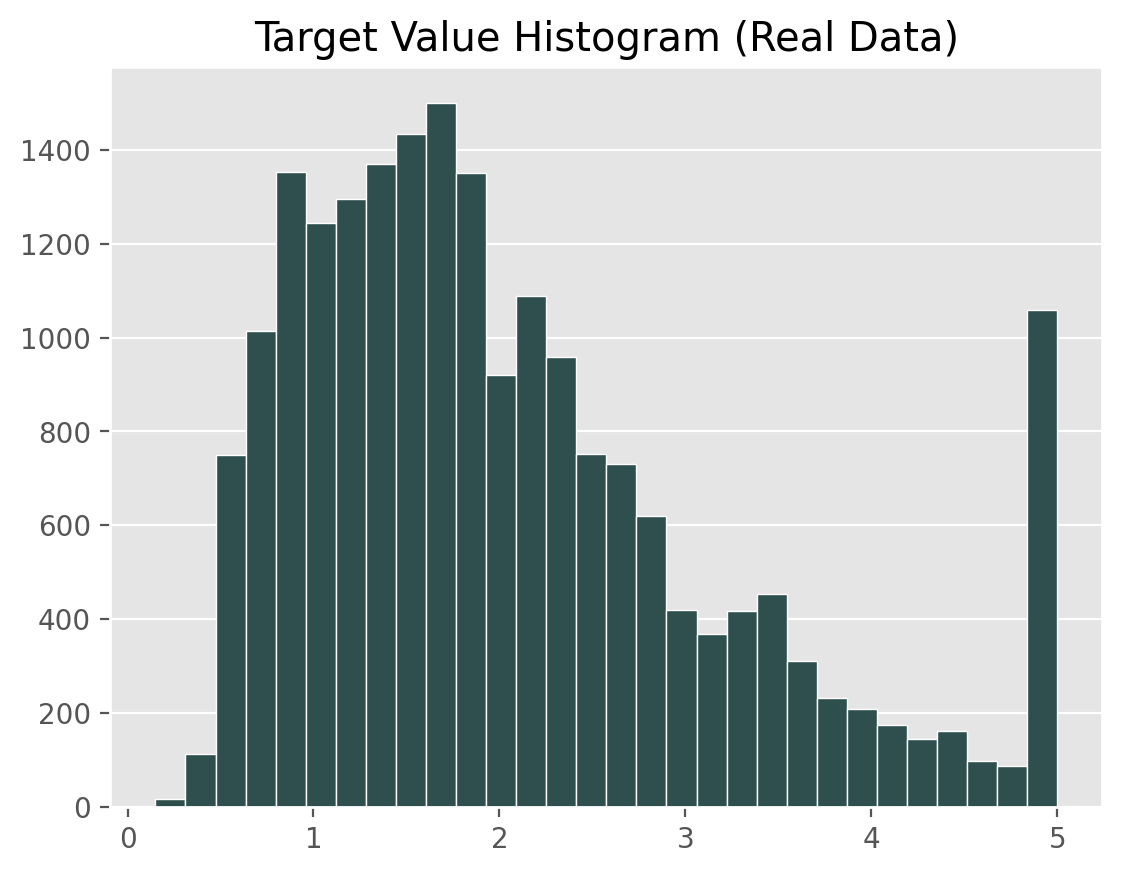

In [5]:
plt.rcParams['figure.dpi'] = 200
plt.title('Target Value Histogram (Real Data)')
plt.hist(Y_real, bins = 30, edgecolor='white', color = "darkslategray")
plt.grid(True, axis = 'x', alpha = 0)
plt.show()

### Since there is a spike at 5 (which correspondes to value of \$500,000), it's probably the case that the data has beed caped for houses with values more than \$500,000. So, to have a more natural data and avoid inflating MSE for those observations, rows corresponding to those houses will be omitted.

In [6]:
X_real = X_real[Y_real < 5]
Y_real = Y_real[Y_real < 5]
num_observations_new = X_real.shape[0]
print(f"Number of observations: {num_observations_new}")
print(f"Number of omitted observations: {num_observations - num_observations_new}")

Number of observations: 19648
Number of omitted observations: 992


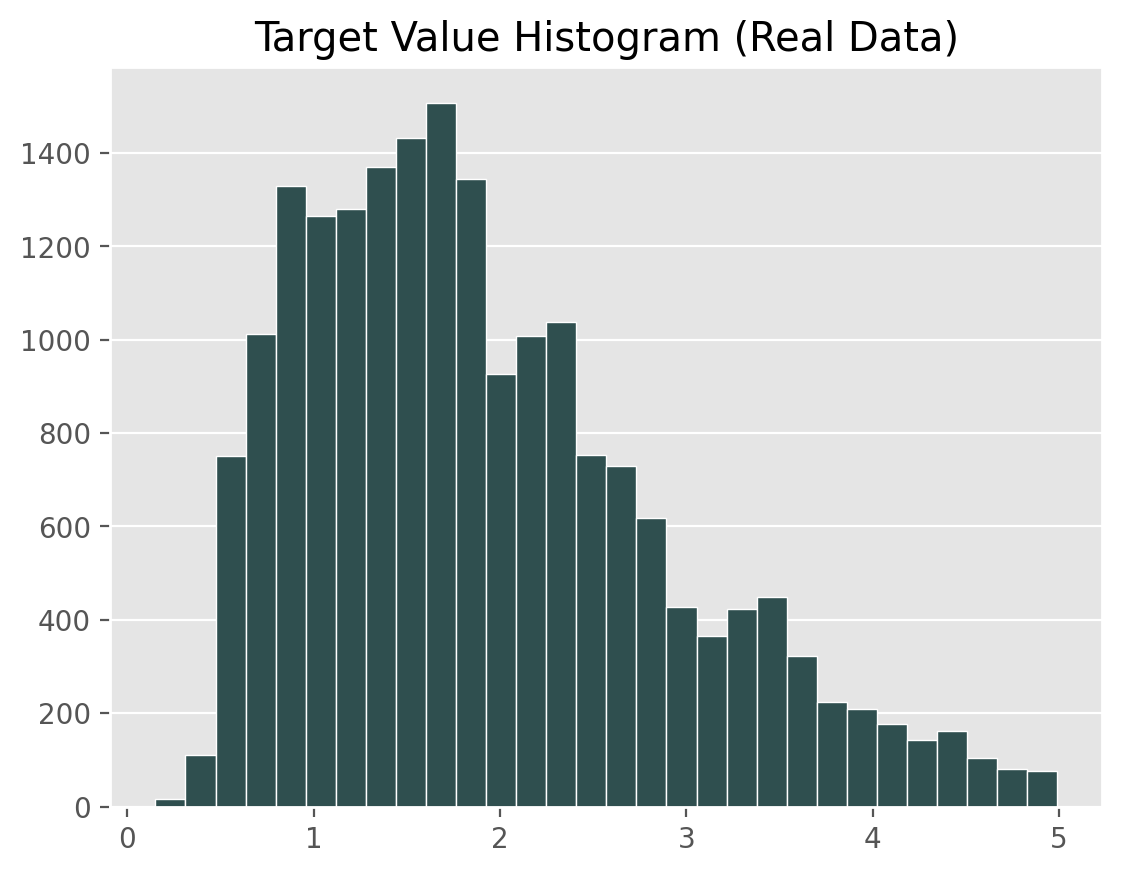

In [7]:
plt.rcParams['figure.dpi'] = 200
plt.title('Target Value Histogram (Real Data)')
plt.hist(Y_real, bins = 30, edgecolor = 'white', color = "darkslategray")
plt.grid(True, axis = 'x', alpha = 0)
plt.show()

## Correlation Matrix (Real Data)

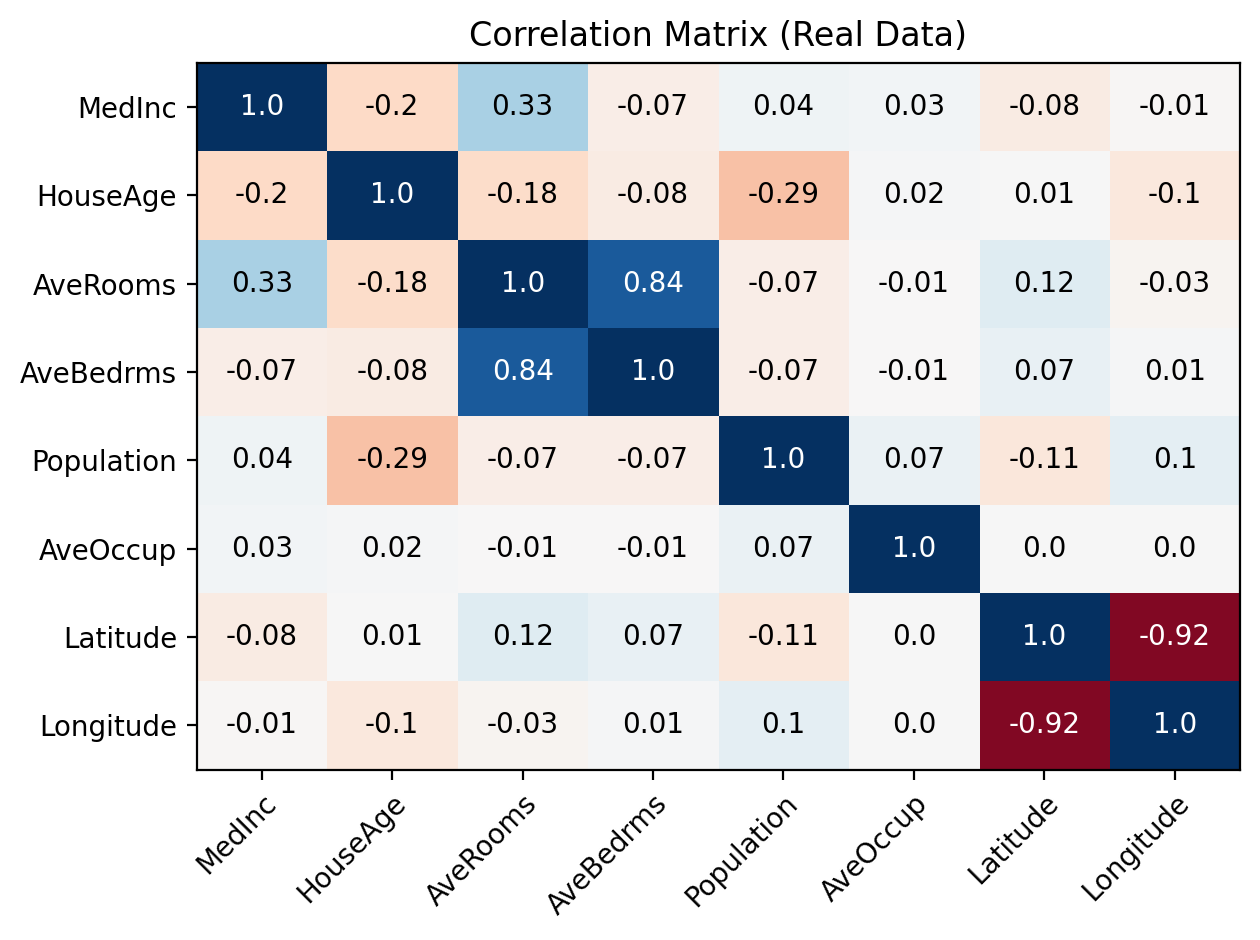

In [8]:
X_scaled = standardize(X_real)
corr_matrix = corr(X_scaled.to_numpy())

plt.style.use("default")
plt.rcParams['figure.dpi'] = 200
fig, ax = plt.subplots()
im = ax.imshow(corr_matrix, cmap = 'RdBu', aspect = 'auto', vmin = -1, vmax = 1)
ax.set_xticks(range(len(X_scaled.columns)), labels = X_scaled.columns,
              rotation = 45, ha = "right", rotation_mode = "anchor")
ax.set_yticks(range(len(X_scaled.columns)), labels = X_scaled.columns)
for i in range(len(X_scaled.columns)):
    for j in range(len(X_scaled.columns)):
        text = ax.text(j, i, np.round(corr_matrix[i, j], 2),
                       ha = "center", va = "center", color = "w" if abs(corr_matrix[i, j]) > 0.5 else "black")

ax.set_title("Correlation Matrix (Real Data)")
fig.tight_layout()
plt.show()

## Features Distributions

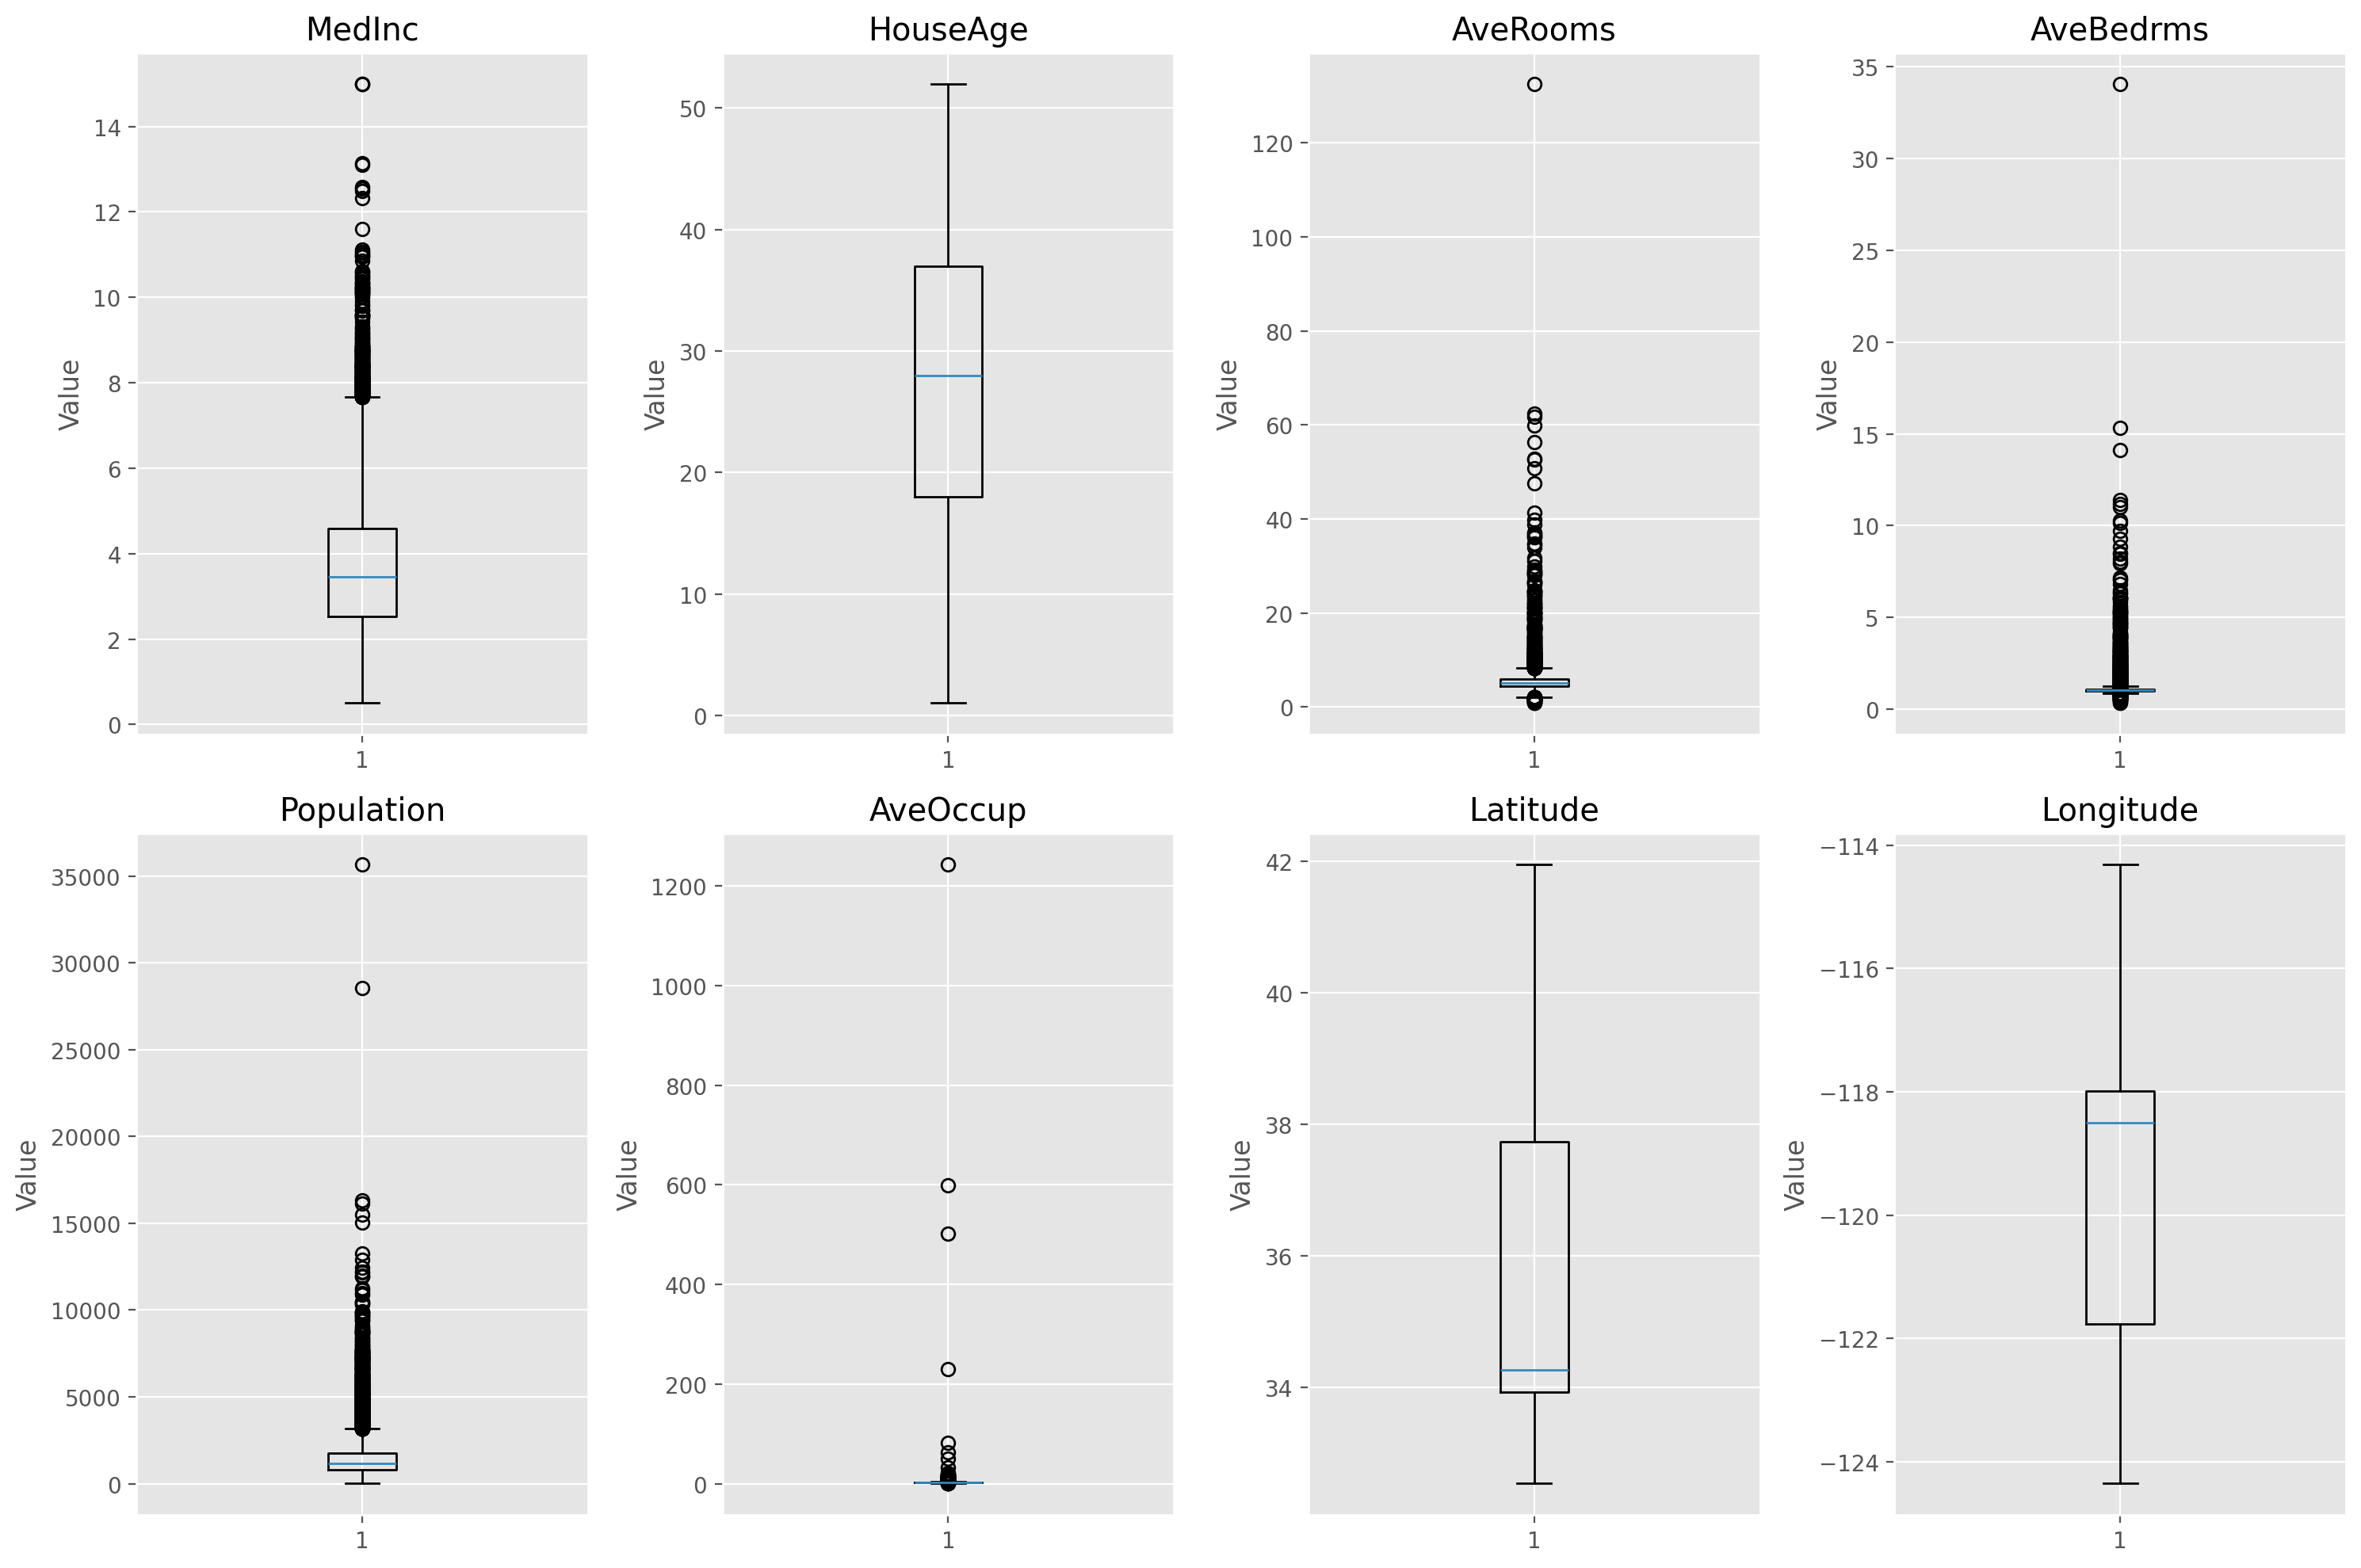

In [9]:
plt.rcParams['figure.dpi'] = 200
plt.style.use('ggplot')

fig, axes = plt.subplots(nrows = 2, ncols = 4, figsize = (15, 10))
axes = axes.flatten()

for i, column in enumerate(X_real.columns):
    axes[i].boxplot(X_real[column])
    axes[i].set_title(column)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

## Generating Synthetic Dataset

In [10]:
syn_observations = 20000
syn_features = 10
x_syn, y_syn, w_syn, noise = dgp(syn_observations, syn_features, dist = 'normal')
X_syn = pd.DataFrame(x_syn)
Y_syn = pd.Series(y_syn.flatten())
print(f"Number of observations: {syn_observations}")
print(f"Number of features: {syn_features}")


Number of observations: 20000
Number of features: 10


## Target Value Histogram (Synthetic Data)

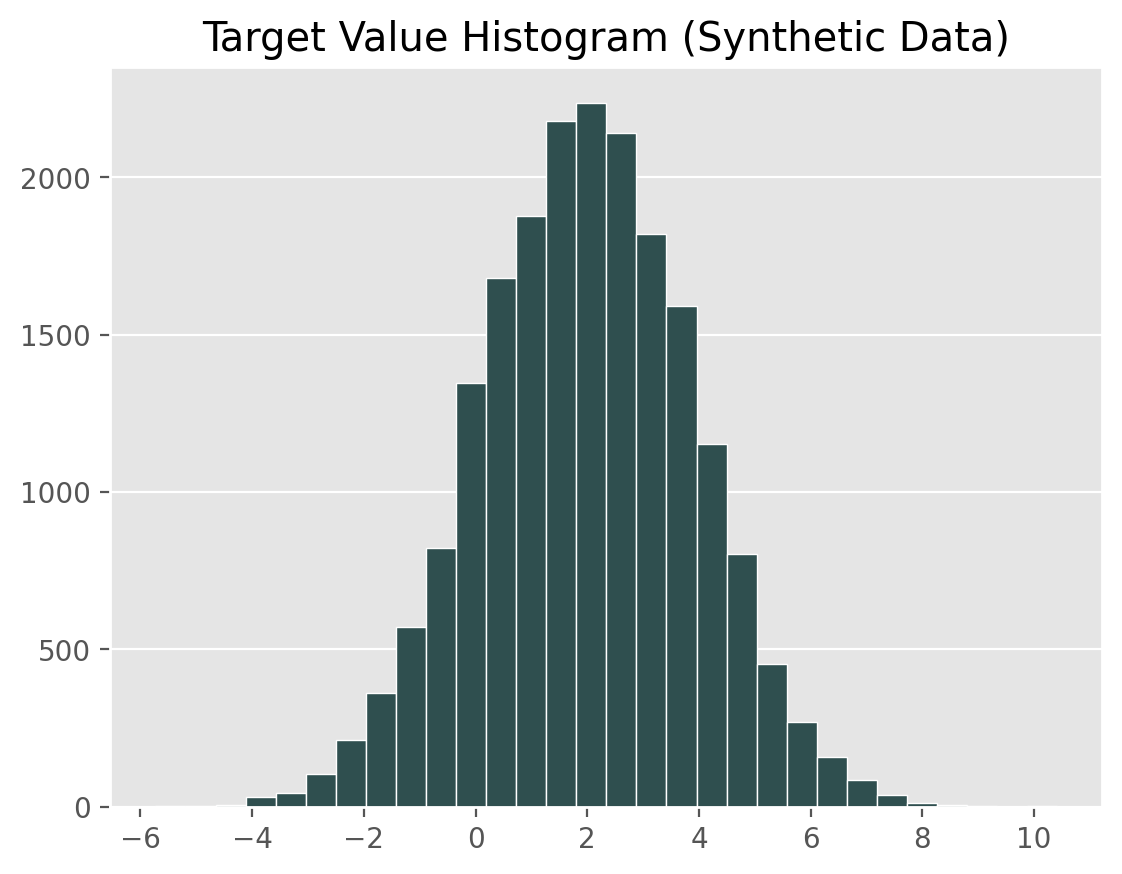

In [11]:
plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 200
plt.title('Target Value Histogram (Synthetic Data)')
plt.rcParams.update({'font.size': 8})
plt.hist(Y_syn, bins = 30, edgecolor = 'white', color = "darkslategray")
plt.grid(True, axis = 'x', alpha = 0)
plt.show()

## Noise Histogram

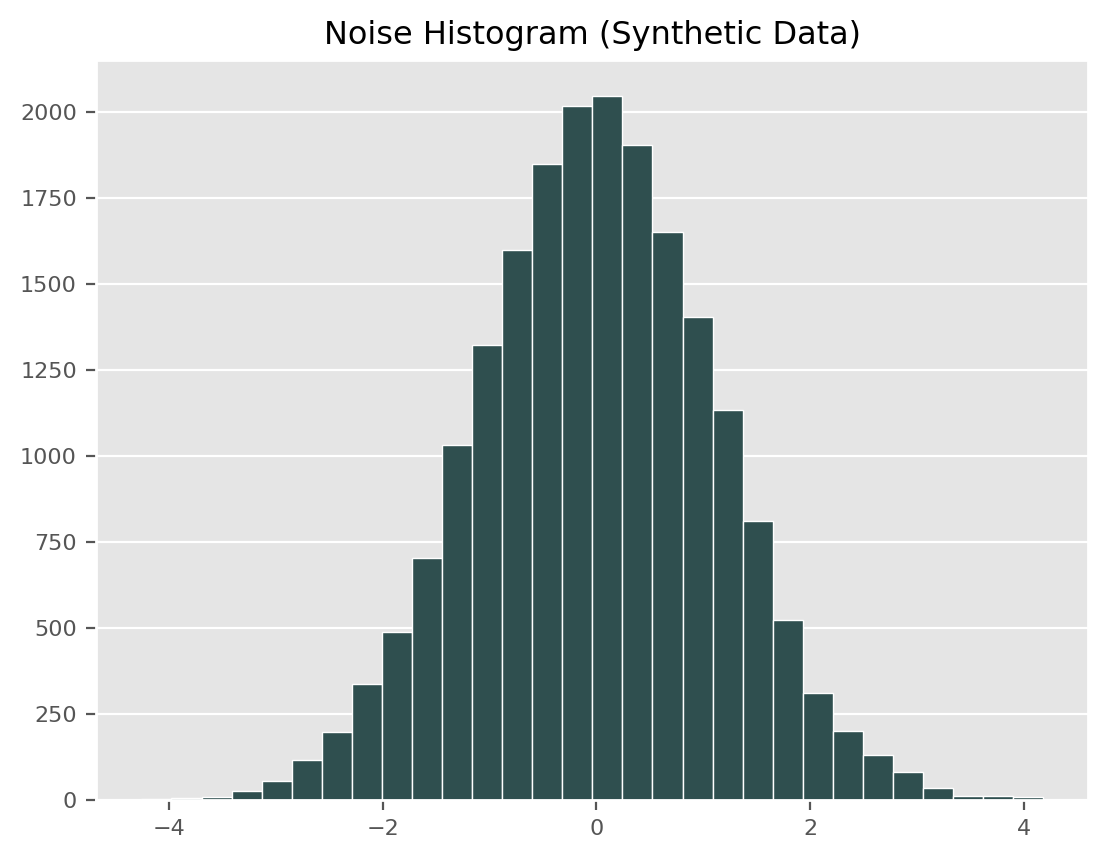

In [12]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 400
plt.title('Noise Histogram (Synthetic Data)')
plt.style.use('ggplot')
plt.hist(noise, bins = 30, edgecolor = 'white', color = "darkslategray")
plt.grid(True, axis = 'x', alpha = 0)
plt.show()

## Correlation Matrix (Synthetic Data)

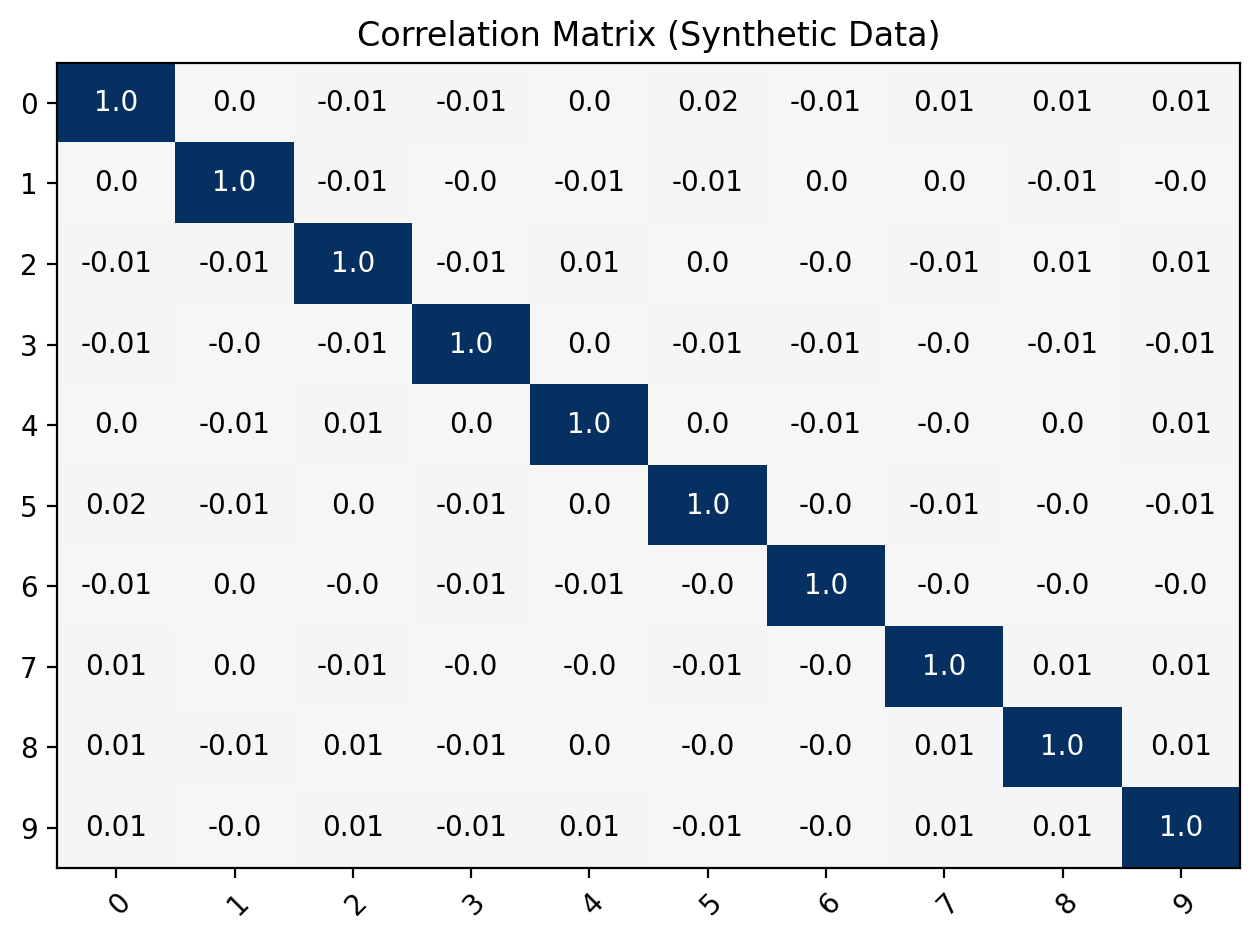

In [13]:
X_syn_scaled = standardize(X_syn)
corr_matrix = corr(X_syn_scaled.to_numpy())

plt.style.use("default")
plt.rcParams['figure.dpi'] = 200
fig, ax = plt.subplots()
im = ax.imshow(corr_matrix, cmap = 'RdBu', aspect = 'auto', vmin = -1, vmax = 1)
ax.set_xticks(range(len(X_syn_scaled.columns)), labels = X_syn_scaled.columns,
              rotation = 45, ha = "right", rotation_mode = "anchor")
ax.set_yticks(range(len(X_syn_scaled.columns)), labels = X_syn_scaled.columns)
for i in range(len(X_syn_scaled.columns)):
    for j in range(len(X_syn_scaled.columns)):
        text = ax.text(j, i, np.round(corr_matrix[i, j], 2),
                       ha = "center", va = "center", color = "w" if abs(corr_matrix[i, j]) > 0.5 else "black")

ax.set_title("Correlation Matrix (Synthetic Data)")
fig.tight_layout()
plt.show()

# Training the Model

In [14]:
# Iterate over different values of the regularization parameter (lambda) and subsample sizes, create a stability object for each combination, compute the stability measures, and store the results in a DataFrame.
dfs = []
i = 0
for X, Y in [(X_real, Y_real), (X_syn, Y_syn)]:
  results = []
  for lambda_val in [0, 0.1, 1, 10, 100, 1000, 10000]:
    for subsample_size in [100, 500, 1000, 5000, 10000, int(X.shape[0] * 0.8)]:
      model = stability(X, Y, lambda_val, subsample_size)
      train_error, mse_full, avg_stability, gap = model.measures()
      results.append((lambda_val, subsample_size, train_error, mse_full, avg_stability, gap))
  results_df = pd.DataFrame(results, columns = ['Lambda', 'Subsample Size', 'Train Error', 'MSE Full', 'Avg Stability', 'Gap'])
  results_df.index.name = 'Real Data' if i == 0 else 'Synthetic Data'
  i += 1
  dfs.append(results_df)

# Plots

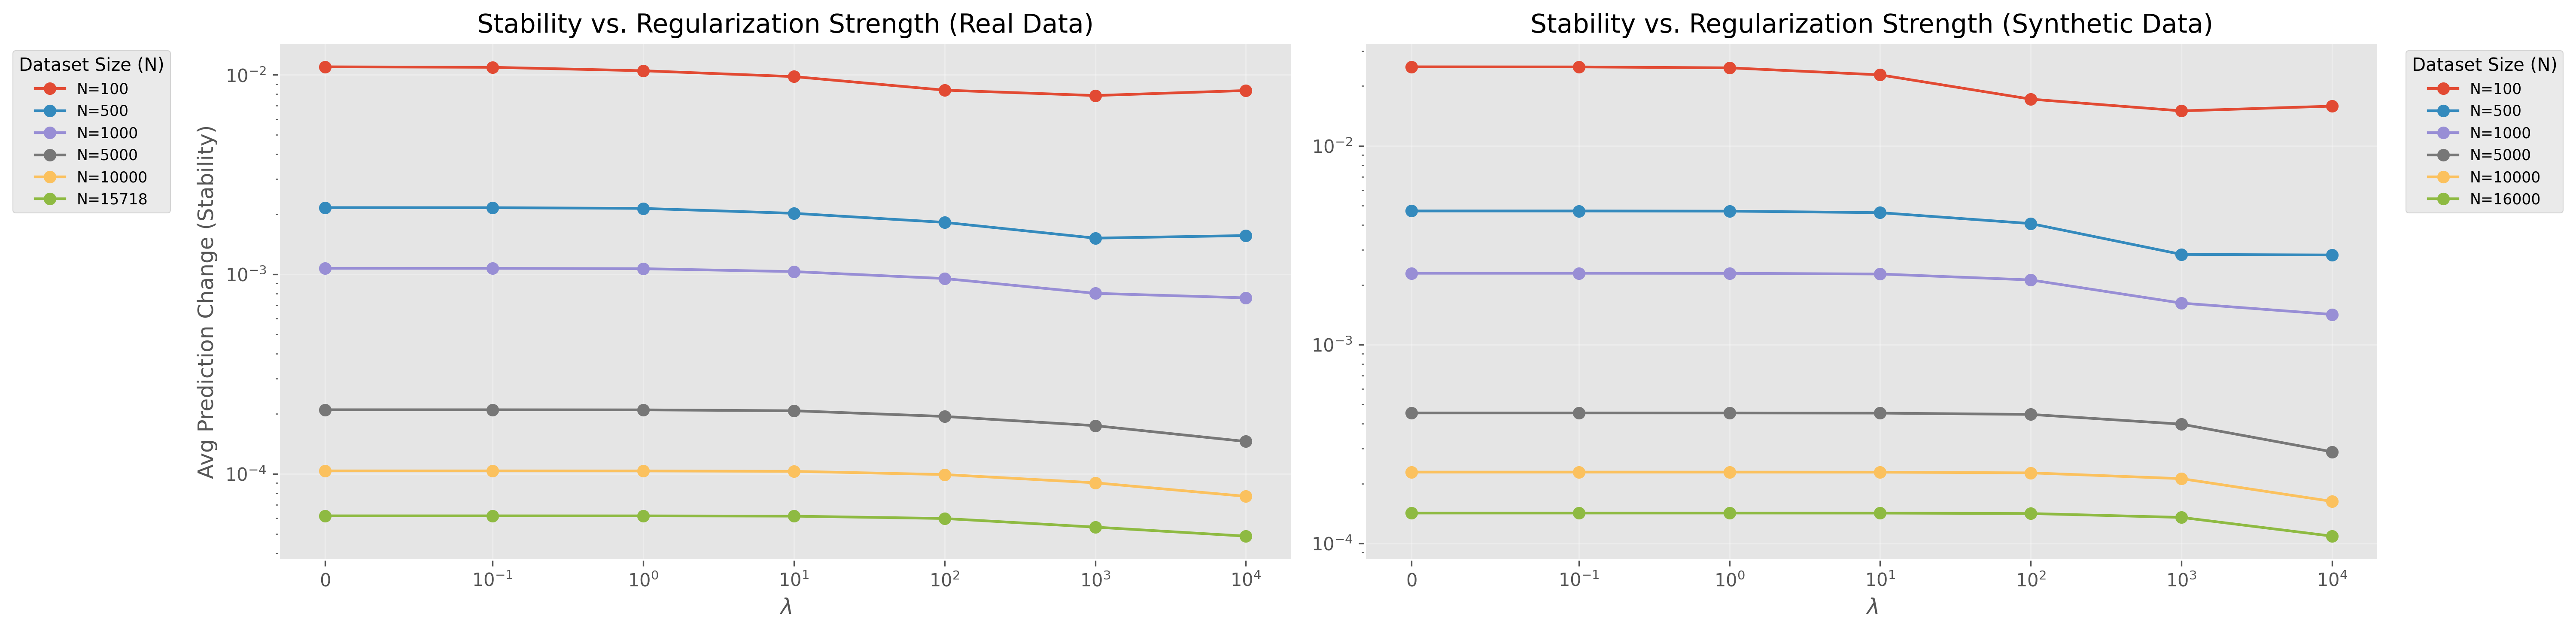

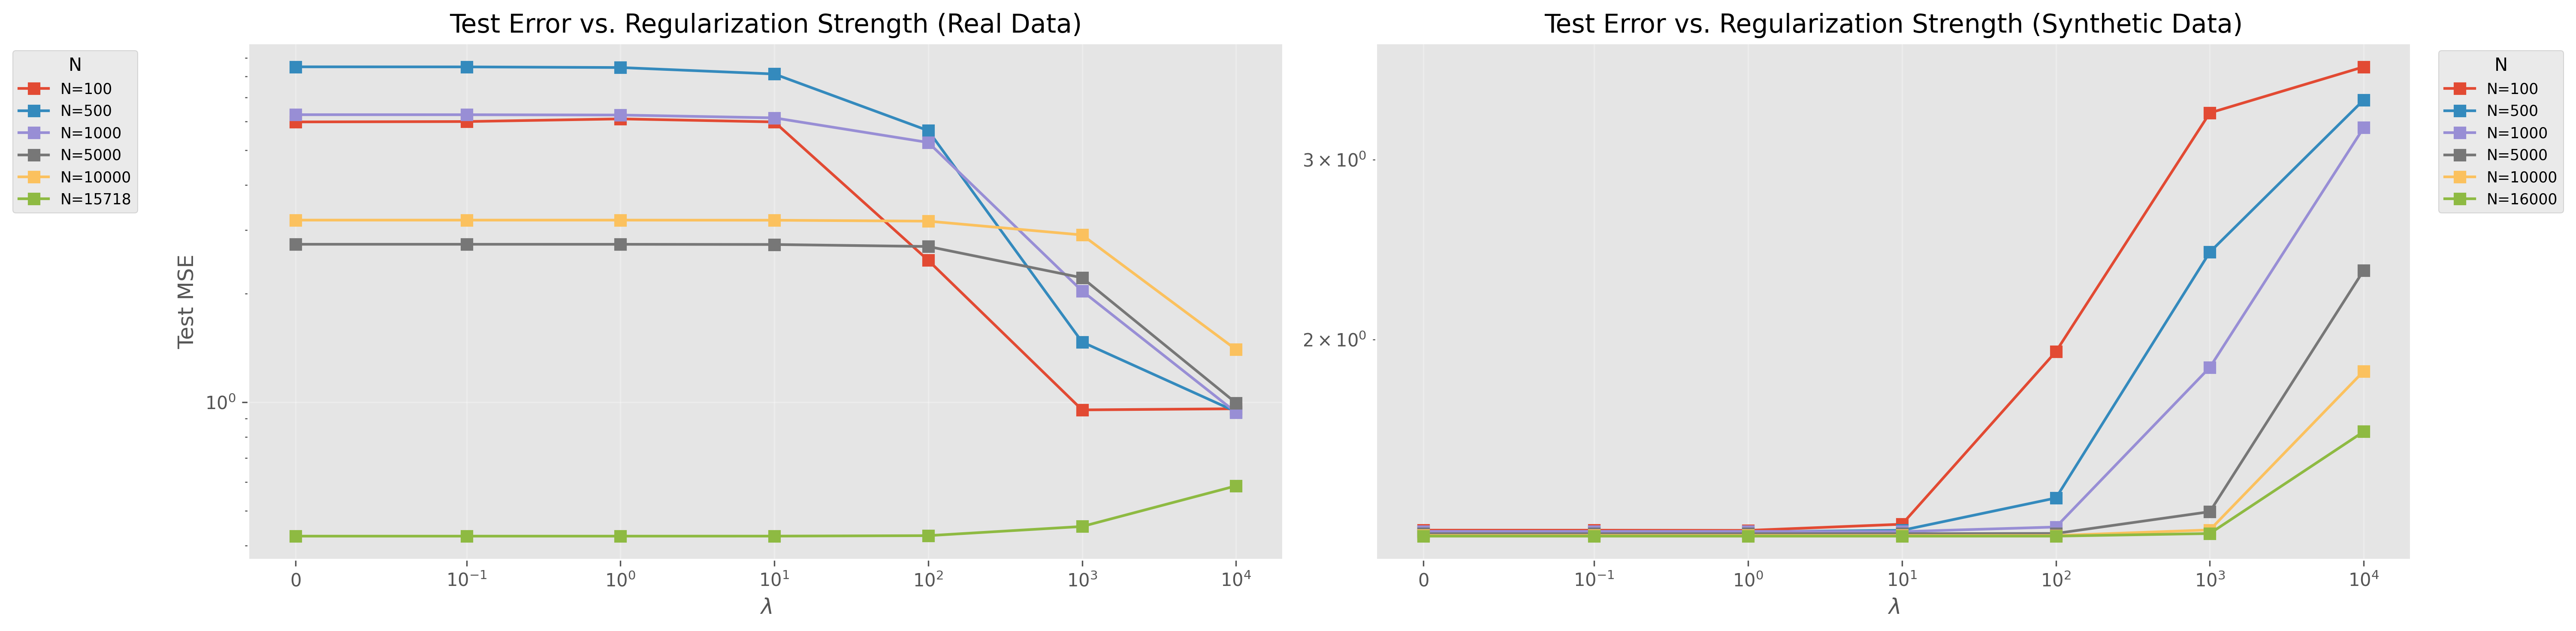

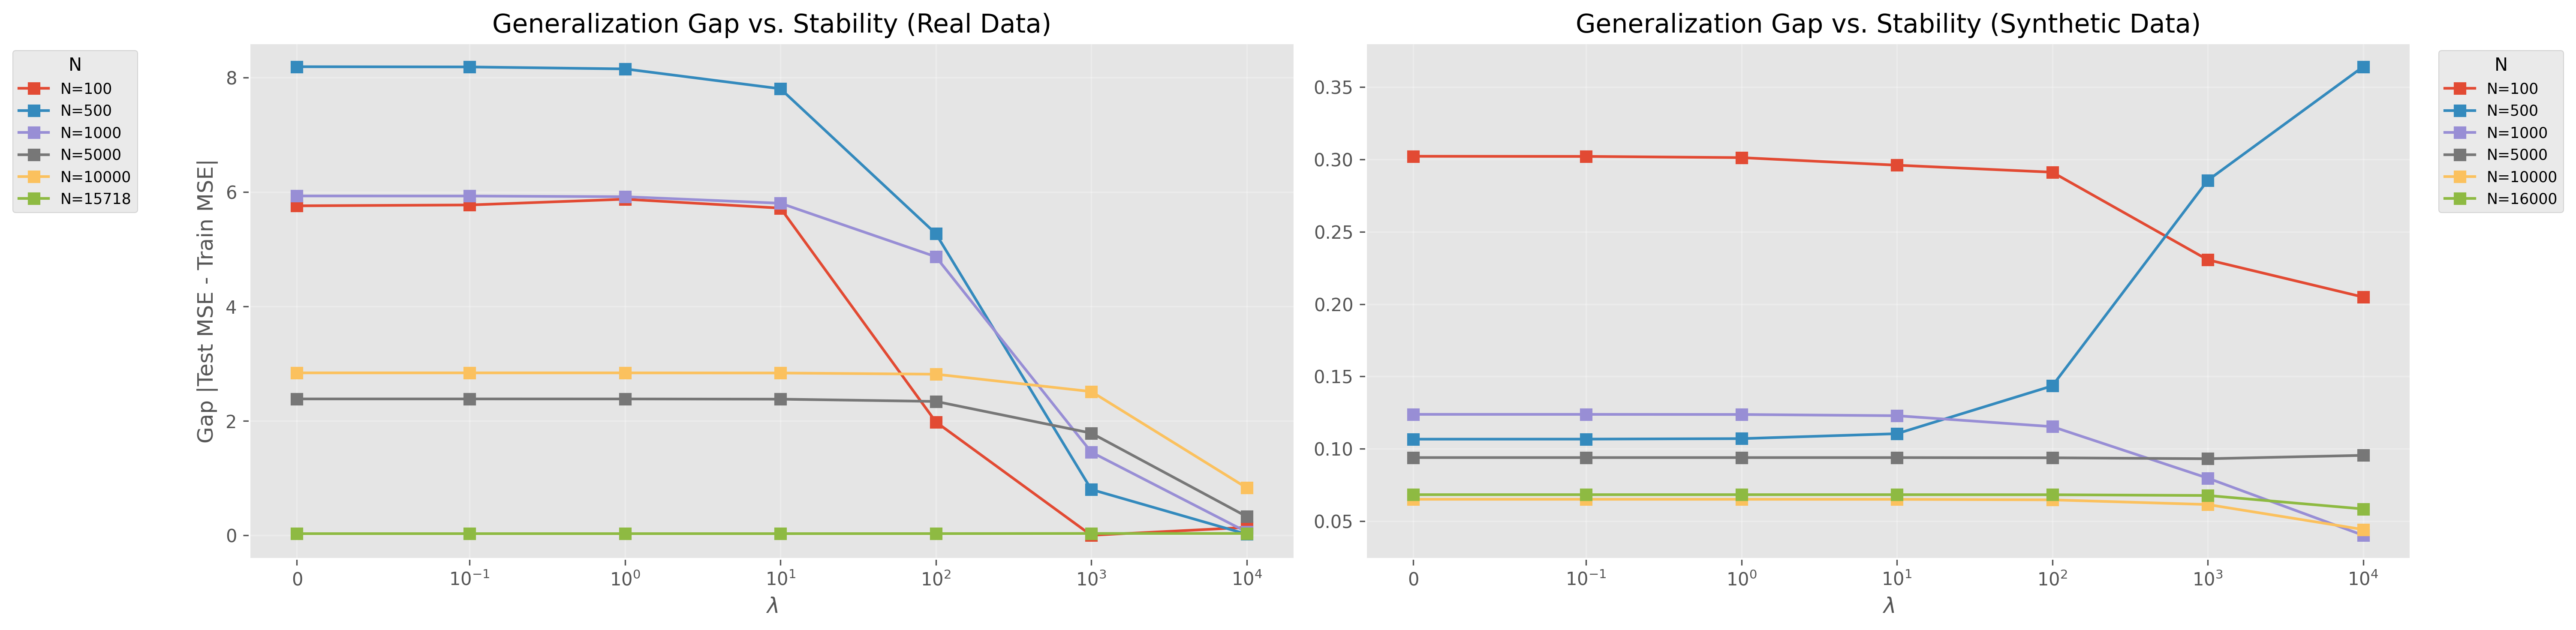

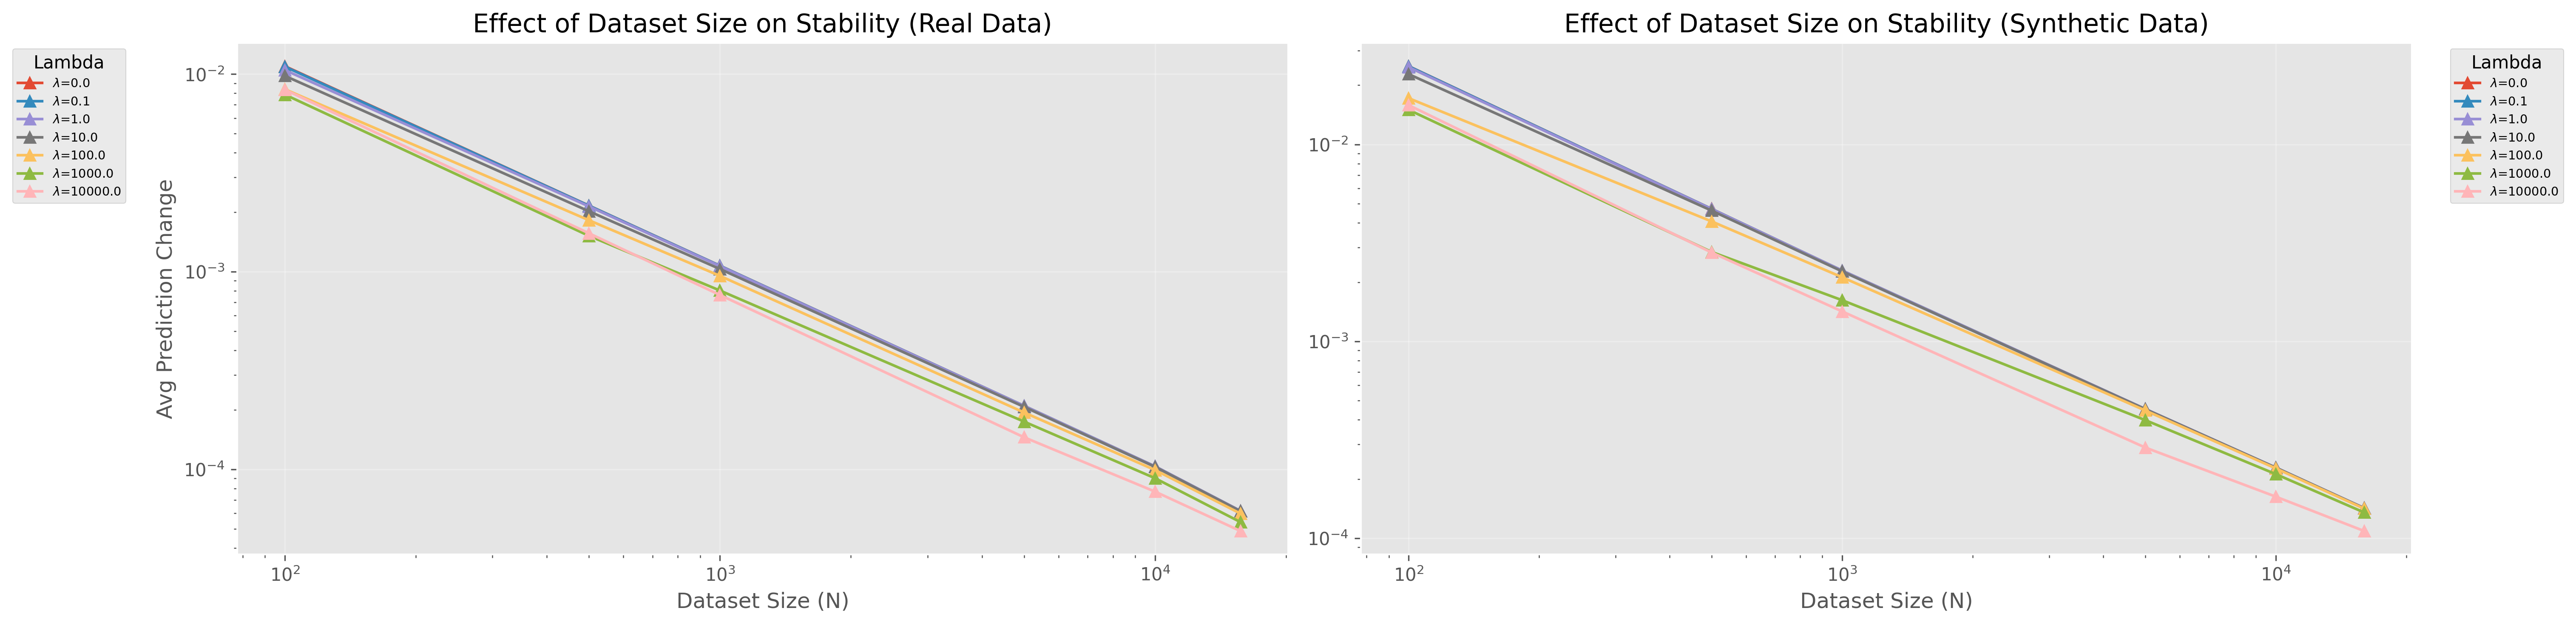

In [15]:
lam = r'$\lambda$'

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.style.use('ggplot')

# Iterate through each plot type (case)
for j in range(4):
  fig, axes_row = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 5))

  for i, df in enumerate(dfs): # i = 0 for Real Data, i = 1 for Synthetic Data
    ax = axes_row[i]

    data_name = df.index.name

    match j:
      case 0:
        for size in sorted(df['Subsample Size'].unique()):
            subset = df[df['Subsample Size'] == size]
            ax.plot(subset['Lambda'], subset['Avg Stability'], marker = 'o', label = f'N={size}')
        ax.set_xscale('symlog', linthresh = 0.1)
        ax.set_yscale('log')
        ax.set_title(f'Stability vs. Regularization Strength ({data_name})')
        ax.set_xlabel(lam)
        ax.set_ylabel('Avg Prediction Change (Stability)' if i == 0 else '')
        ax.legend(title = "Dataset Size (N)", fontsize = 'small', bbox_to_anchor = (-0.10, 1) if i == 0 else (1.02, 1), loc = 0)
        ax.grid(True, alpha = 0.3)
      case 1:
        for size in sorted(df['Subsample Size'].unique()):
          subset = df[df['Subsample Size'] == size]
          ax.plot(subset['Lambda'], subset['MSE Full'], marker = 's', label = f'N={size}')

        ax.set_xscale('symlog', linthresh = 0.1)
        ax.set_yscale('log')
        ax.set_title(f'Test Error vs. Regularization Strength ({data_name})')
        ax.set_xlabel(lam)
        ax.set_ylabel('Test MSE' if i == 0 else '')
        ax.legend(title = "N", fontsize = 'small', bbox_to_anchor = (-0.10, 1) if i == 0 else (1.02, 1), loc = 0)
        ax.grid(True, alpha = 0.3)
      case 2:
        for size in sorted(df['Subsample Size'].unique()):
          subset = df[df['Subsample Size'] == size]
          ax.plot(subset['Lambda'], subset['Gap'], marker = 's', label = f'N={size}')

        ax.set_xscale('symlog', linthresh = 0.1)
        ax.set_title(f'Generalization Gap vs. Stability ({data_name})')
        ax.set_xlabel(lam)
        ax.set_ylabel('Gap |Test MSE - Train MSE|' if i == 0 else '')
        ax.legend(title = "N", fontsize = 'small', bbox_to_anchor = (-0.10, 1) if i == 0 else (1.02, 1), loc = 0)
        ax.grid(True, alpha = 0.3)
      case 3:
        for l in sorted(df['Lambda'].unique()):
          subset = df[df['Lambda'] == l]
          ax.plot(subset['Subsample Size'], subset['Avg Stability'], marker = '^', label = f'{lam}={l}')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(f'Effect of Dataset Size on Stability ({data_name})')
        ax.set_xlabel('Dataset Size (N)')
        ax.set_ylabel('Avg Prediction Change' if i == 0 else '')
        ax.legend(title = "Lambda", fontsize = 'x-small', ncol = 1, bbox_to_anchor = (-0.10, 1) if i == 0 else (1.15, 1), loc = 0)
        ax.grid(True, alpha = 0.3)

  plt.tight_layout()
  plt.show()